# EDA Silver Layer
---

En este cuadernillo se realizará un pequeño análisis exploratorio sobre los datos de la capa `Silver` para entender mejor su estructura y contenido. Este análisis nos ayudará a identificar posibles problemas de calidad de datos, patrones interesantes y áreas que podrían requerir una limpieza adicional antes de avanzar a la capa `Gold`.

Inicialmente, fijamos la ruta al directorio donde se encuentran los datos de la capa `Silver`.

In [1]:
silver_dir = "../../data/silver"

A continuación, mostramos una gráfica la cantidad de imágenes por cada signo. Esto nos permitirá corroborar que hay un equilibrio en la distribución de las clases.

<Axes: title={'center': 'Cantidad de imágenes por cada signo'}, xlabel='letter'>

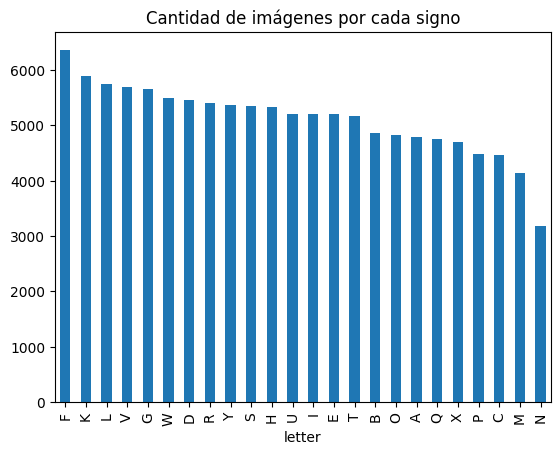

In [2]:
import pandas as pd

# Cargamos el DataFrame de las landmarks de las manos
silver_df = pd.read_csv(f"{silver_dir}/hand_landmarks.csv")

# Mostramos la cantidad de imágenes por cada signo
sign_counts = silver_df["letter"].value_counts()
sign_counts.plot(kind="bar", title="Cantidad de imágenes por cada signo")

Tal y como podemos observar en la gráfica de arriba, pese a que no hay un desbalance extremo, si que hay signos que tienen una cantidad de imágenes significativamente menor que otros, como es el caso de la letra "F" y la "N".

Esto podría afectar el rendimiento de los modelos, por lo que se optará por eliminar un número de registros de las clases más representadas para equilibrar el dataset.

In [3]:
sign_counts

letter
F    6360
K    5887
L    5742
V    5700
G    5662
W    5489
D    5461
R    5394
Y    5367
S    5352
H    5327
U    5211
I    5199
E    5197
T    5169
B    4860
O    4820
A    4795
Q    4759
X    4690
P    4481
C    4461
M    4144
N    3182
Name: count, dtype: int64

Concretamente, se puede ver que para la letra "F" hay 6360 registros, mientras que para la letra "N", únicamente hay 3182. Por ello, se eliminarán registros de todas las clases para que el número de instancias de cada clase sea 3000.

<Axes: title={'center': 'Cantidad de imágenes por cada signo (balanceado)'}, xlabel='letter'>

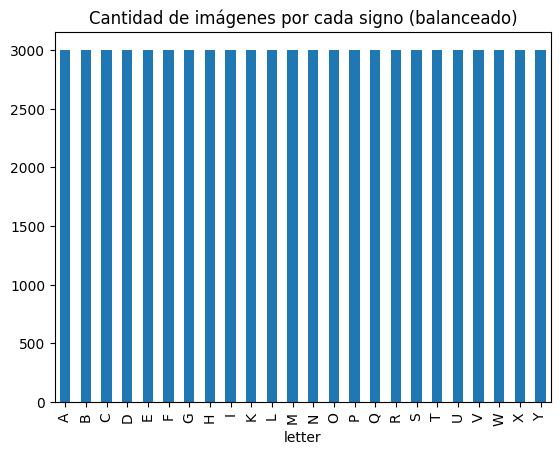

In [4]:
N_INSTANCES_PER_CLASS = 3000

# Eliminamos registros aleatorios hasta que cada clase
# tenga un número de instancias igual a N_INSTANCES_PER_CLASS
balanced_silver_df = (
    silver_df.groupby("letter", group_keys=False)
    .sample(n=N_INSTANCES_PER_CLASS, random_state=42)
    .reset_index(drop=True)
)

balanced_silver_counts = balanced_silver_df["letter"].value_counts()
balanced_silver_counts.plot(kind="bar", title="Cantidad de imágenes por cada signo (balanceado)")

A continuación, mostramos una tabla con un ejemplo por cada clase para verificar que los datos se han manipulado correctamente y que el formato es el esperado.

In [5]:
# Mostramos una tabla con un ejemplo por cada clase para verificar que los datos se han manipulado correctamente y que el formato es el esperado.
balanced_silver_df.groupby("letter").first().drop(columns=["image_path"])

,landmark0_x,landmark0_y,landmark0_z,landmark1_x,landmark1_y,landmark1_z,landmark2_x,landmark2_y,landmark2_z,landmark3_x,...,landmark17_z,landmark18_x,landmark18_y,landmark18_z,landmark19_x,landmark19_y,landmark19_z,landmark20_x,landmark20_y,landmark20_z
letter,,,,,,,,,,,,,,,,,,,,,
A,0.236389,0.502695,-1.581296e-07,0.367288,0.458743,-0.010832,0.449364,0.360857,-0.013496,0.456684,...,-0.043779,0.195367,0.253825,-0.080066,0.210291,0.319470,-0.075583,0.218631,0.372617,-0.064394
B,0.446291,0.778823,8.288060e-08,0.530113,0.728449,-0.030035,0.599280,0.667493,-0.040582,0.593999,...,-0.031276,0.379699,0.474356,-0.045053,0.376444,0.427841,-0.052315,0.372200,0.384440,-0.058068
C,0.067250,0.515112,9.329311e-07,0.171654,0.512380,-0.026197,0.254877,0.478467,-0.035280,0.328389,...,0.002292,0.218053,0.227538,-0.010563,0.273264,0.207704,-0.014434,0.320387,0.204203,-0.014635
D,0.457916,0.978051,3.664894e-07,0.558095,0.939893,-0.024987,0.617851,0.857878,-0.034759,0.668428,...,-0.051255,0.556541,0.693691,-0.093744,0.611086,0.712152,-0.106741,0.632812,0.738622,-0.107658
E,0.317903,0.839813,-1.237225e-07,0.443737,0.757443,-0.042762,0.509866,0.623442,-0.061589,0.410919,...,-0.056284,0.221489,0.415135,-0.098081,0.243972,0.485134,-0.103021,0.266123,0.557731,-0.097760
F,0.375330,0.982398,-3.934613e-07,0.263370,0.934305,-0.071787,0.164439,0.849828,-0.140646,0.108982,...,-0.142180,0.652627,0.537066,-0.167051,0.674499,0.444236,-0.180162,0.672855,0.352058,-0.192980
G,0.741812,0.876077,4.691355e-07,0.828348,0.774532,-0.095885,0.812609,0.598397,-0.134410,0.738182,...,-0.121324,0.410820,0.769557,-0.213825,0.498368,0.820506,-0.198605,0.553564,0.850208,-0.166599
H,0.637972,0.577229,5.310216e-07,0.686073,0.482754,-0.054846,0.635915,0.369344,-0.073023,0.521785,...,-0.084962,0.434644,0.460004,-0.160273,0.514121,0.491775,-0.165970,0.564071,0.513915,-0.154112
I,0.342170,1.057458,-1.341703e-06,0.484631,0.997020,-0.092591,0.557631,0.840111,-0.129845,0.472772,...,-0.036904,0.178189,0.577275,-0.078491,0.167943,0.483833,-0.088720,0.167221,0.402973,-0.088625


Para comprobar que esta extracción de landmarks se ha realizado correctamente, se muestra un dibujo de las coordenadas de los landmarks para una imagen de cada clase.

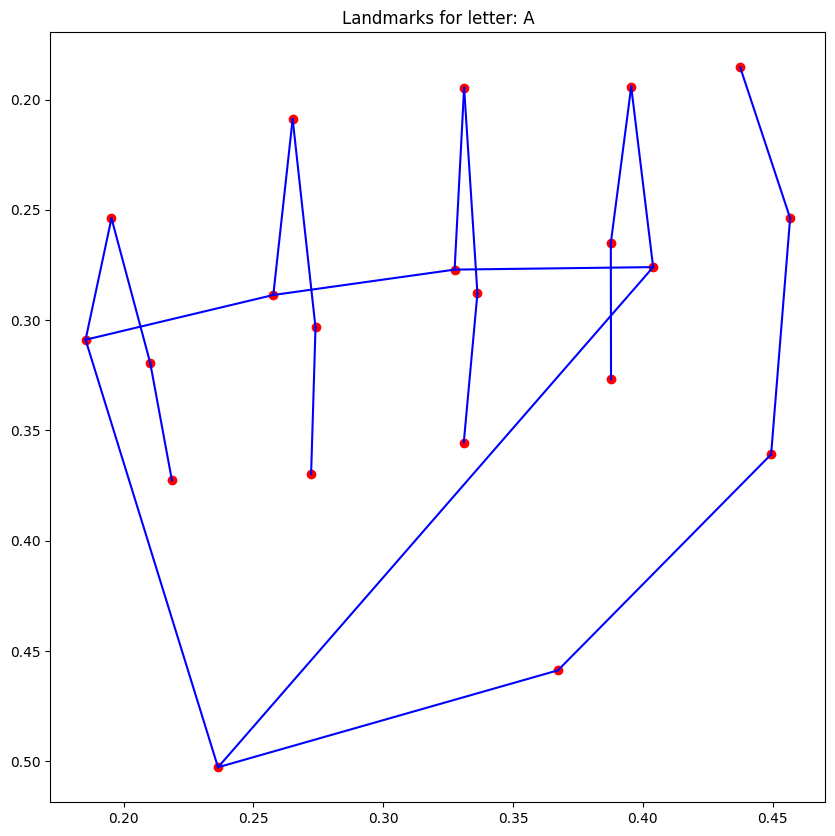

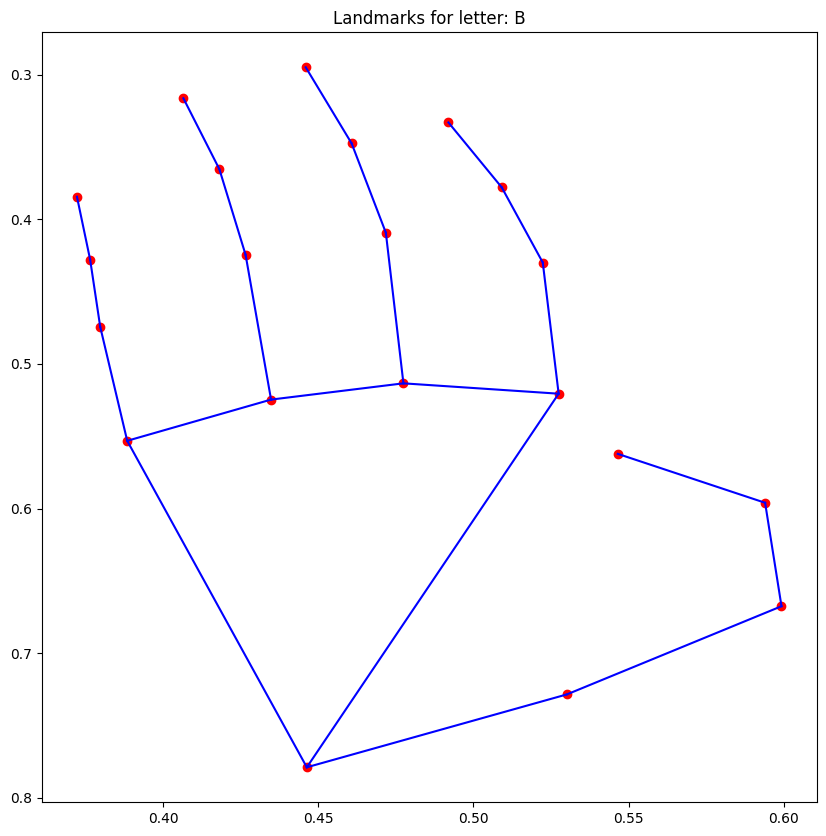

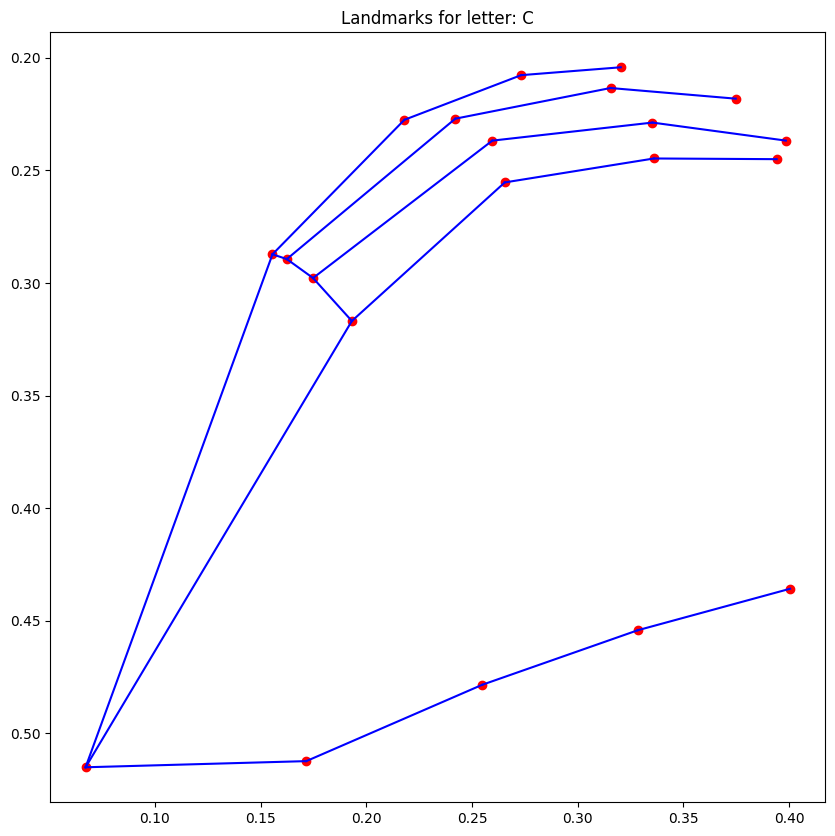

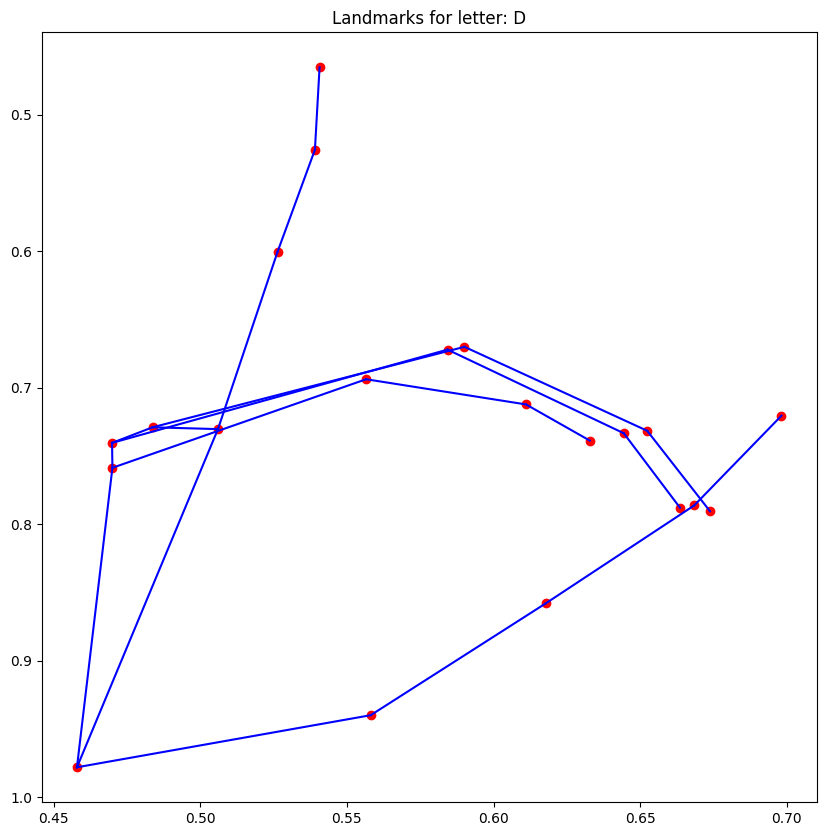

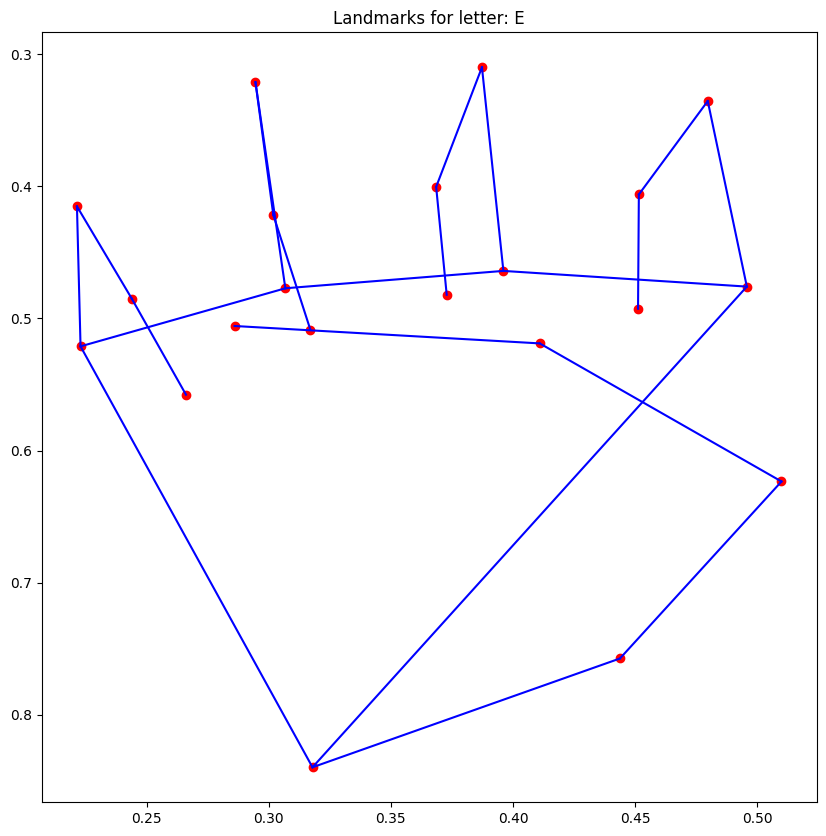

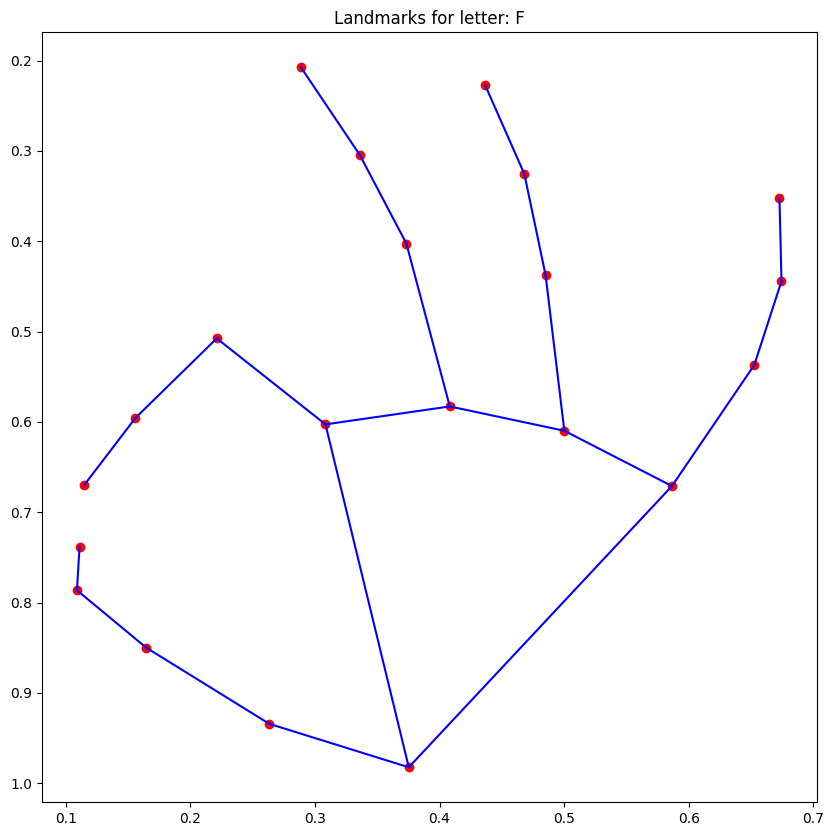

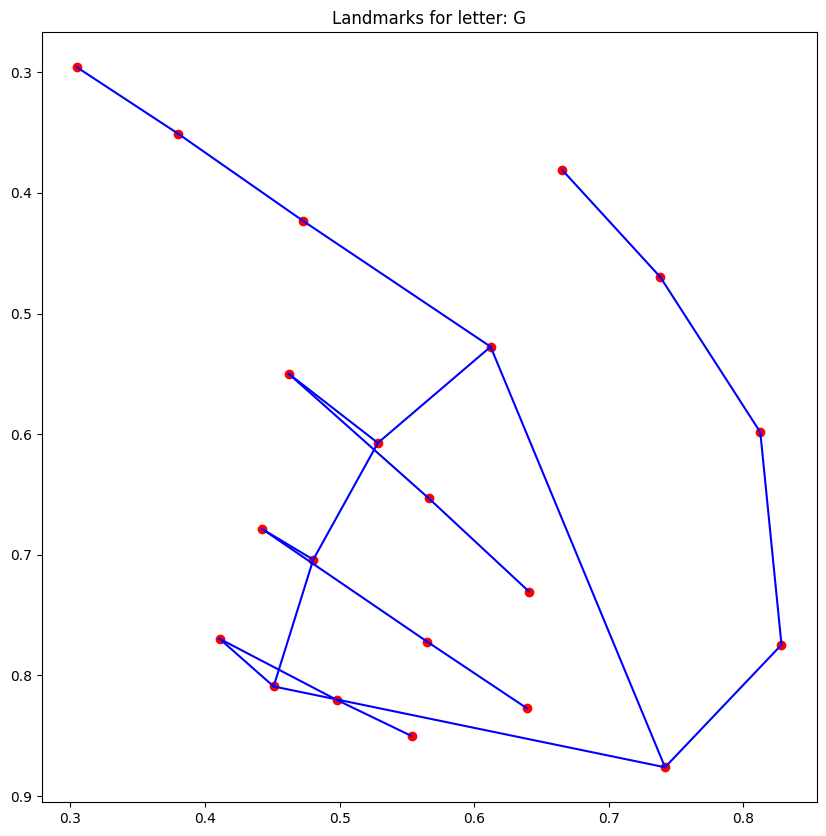

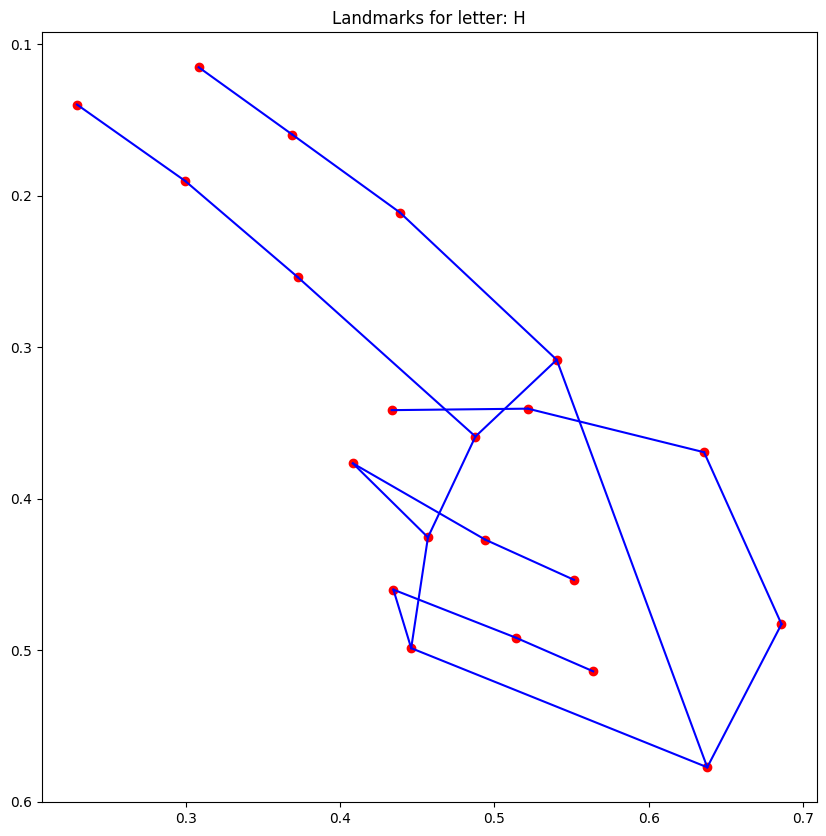

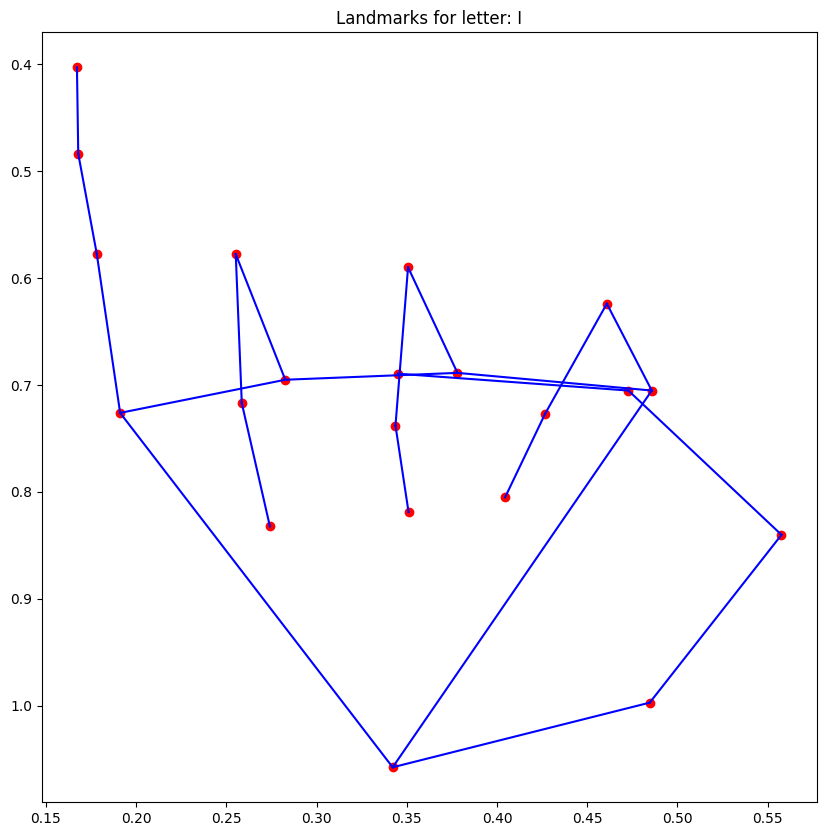

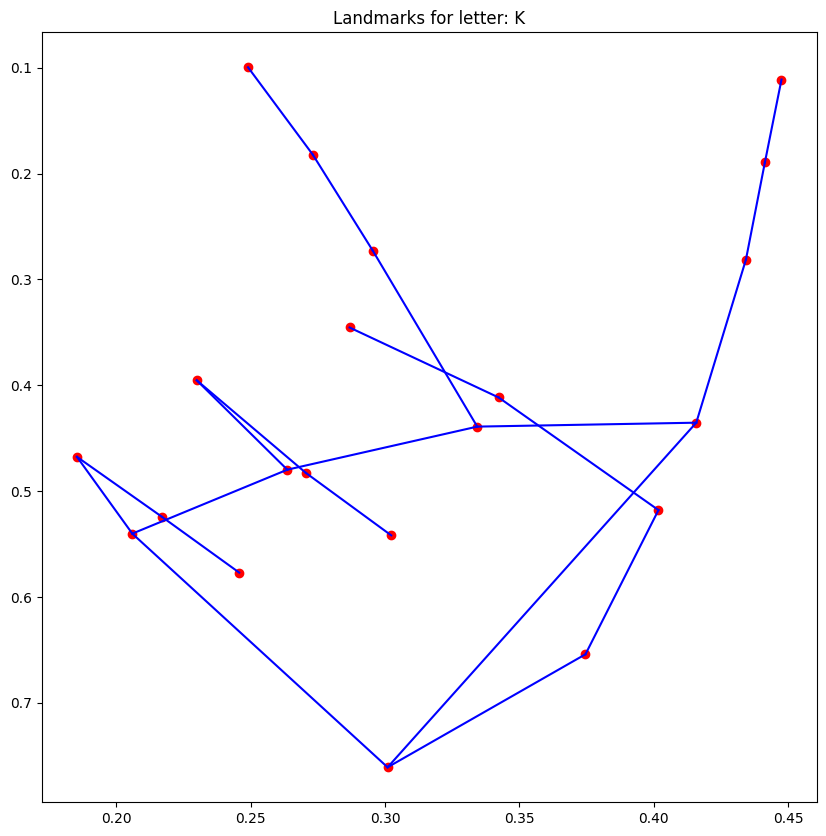

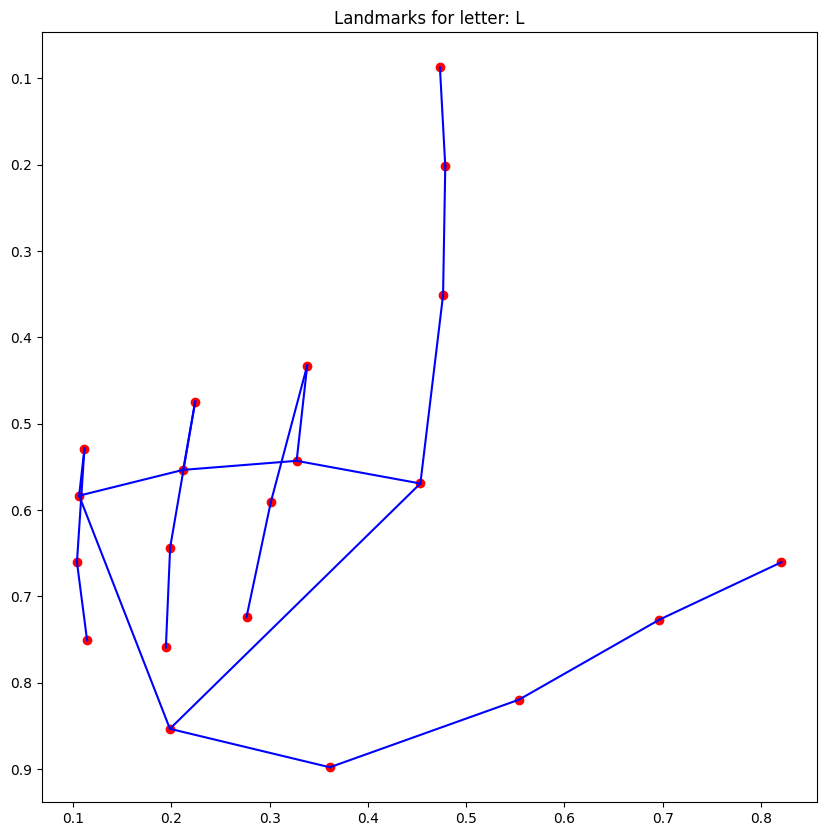

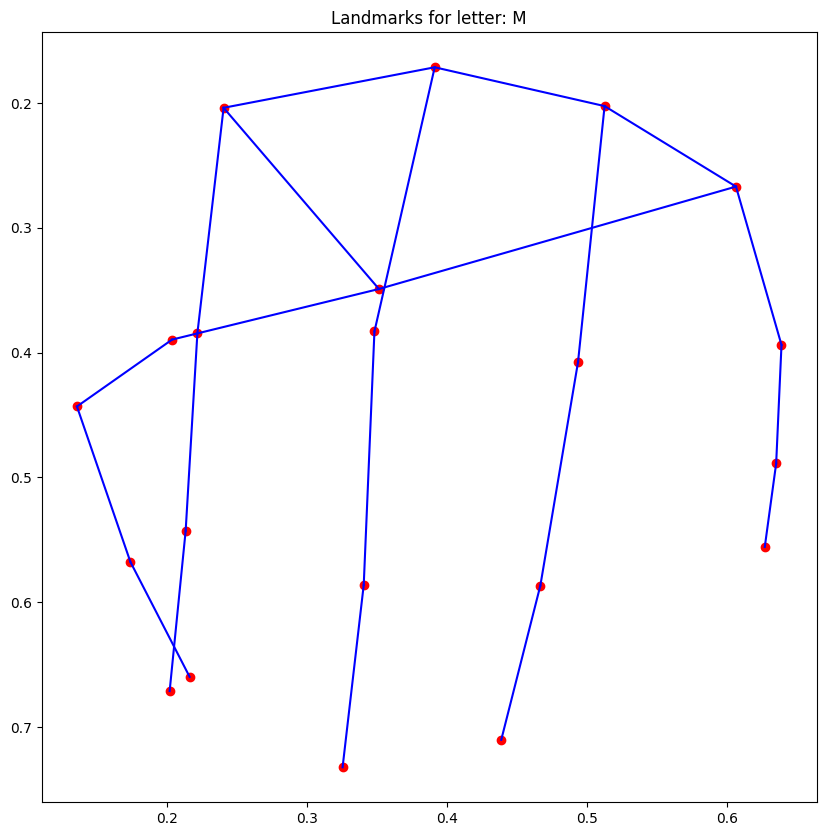

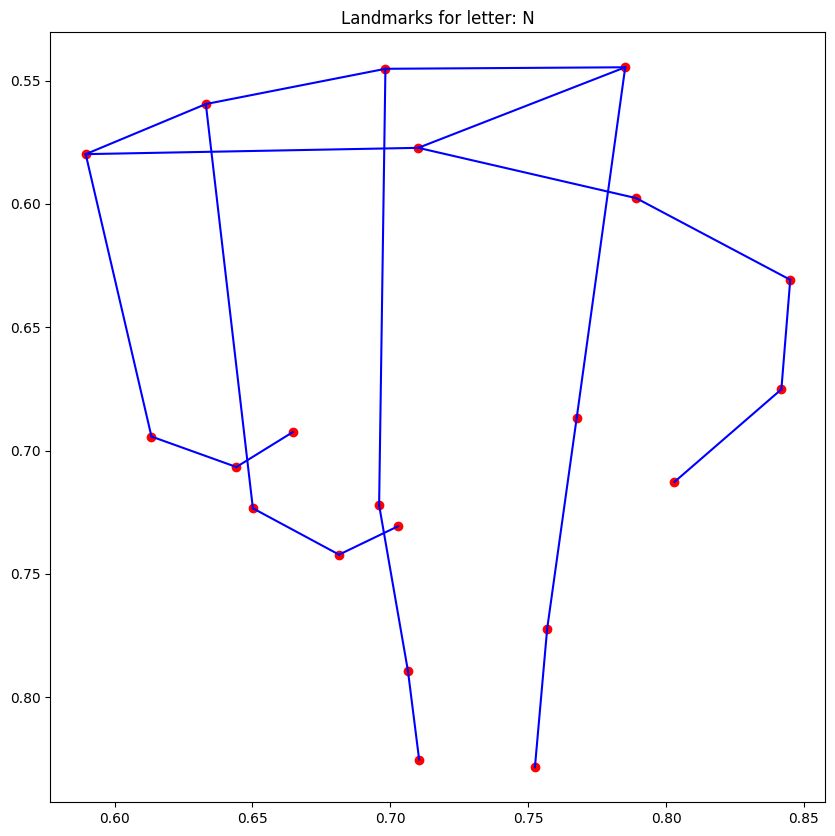

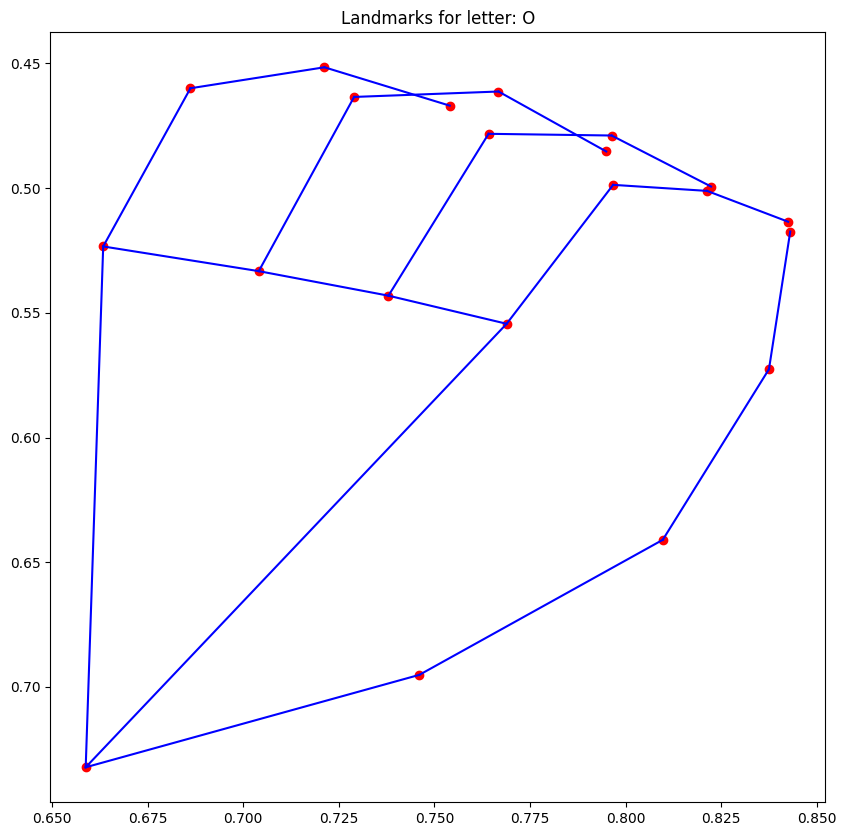

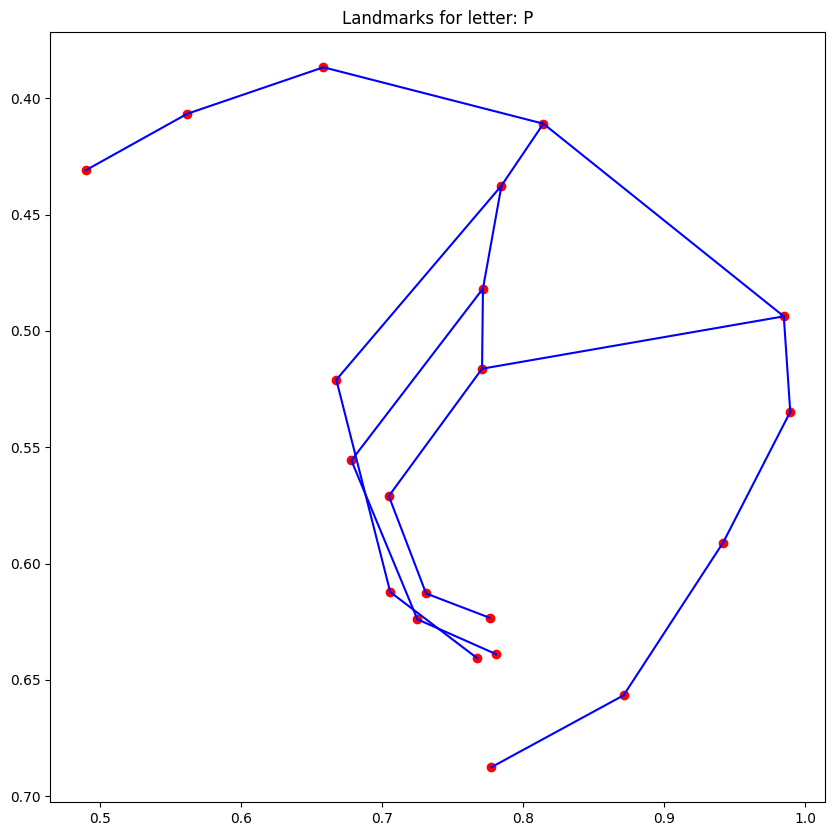

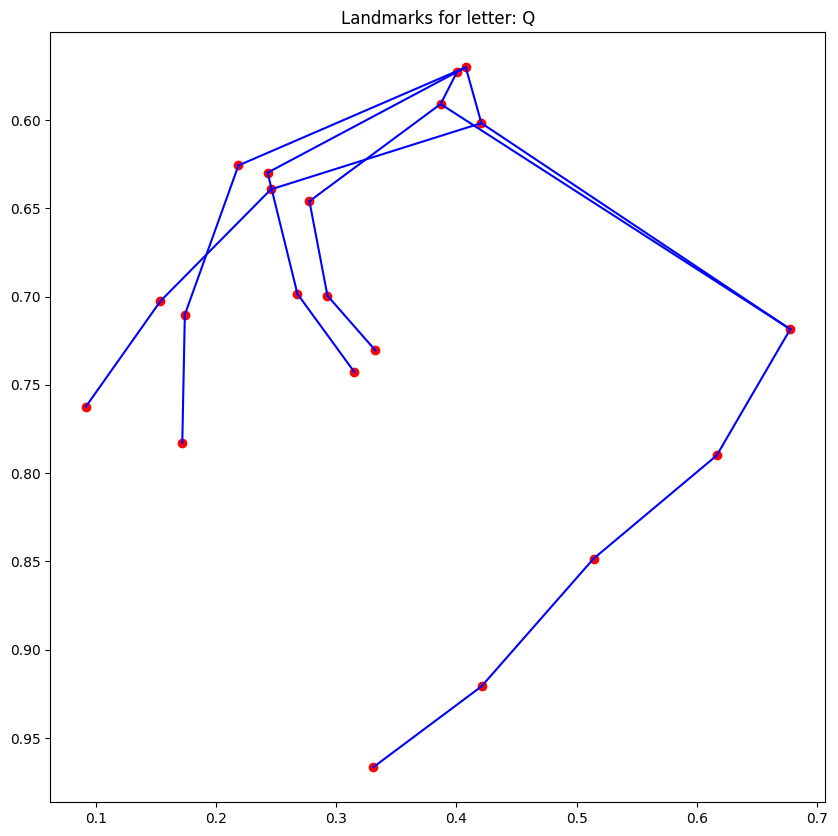

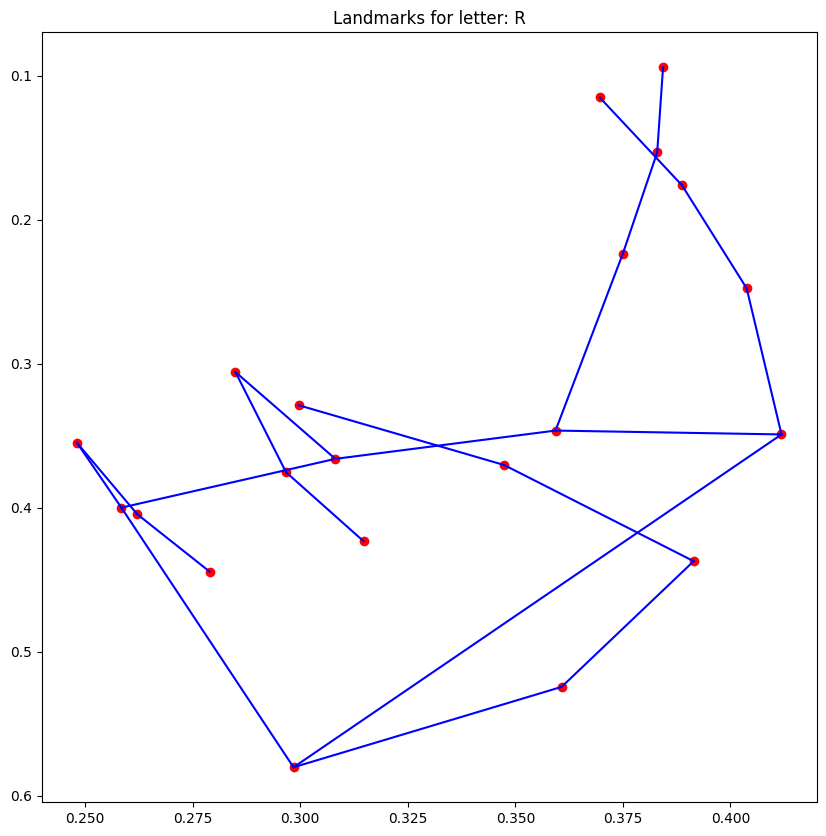

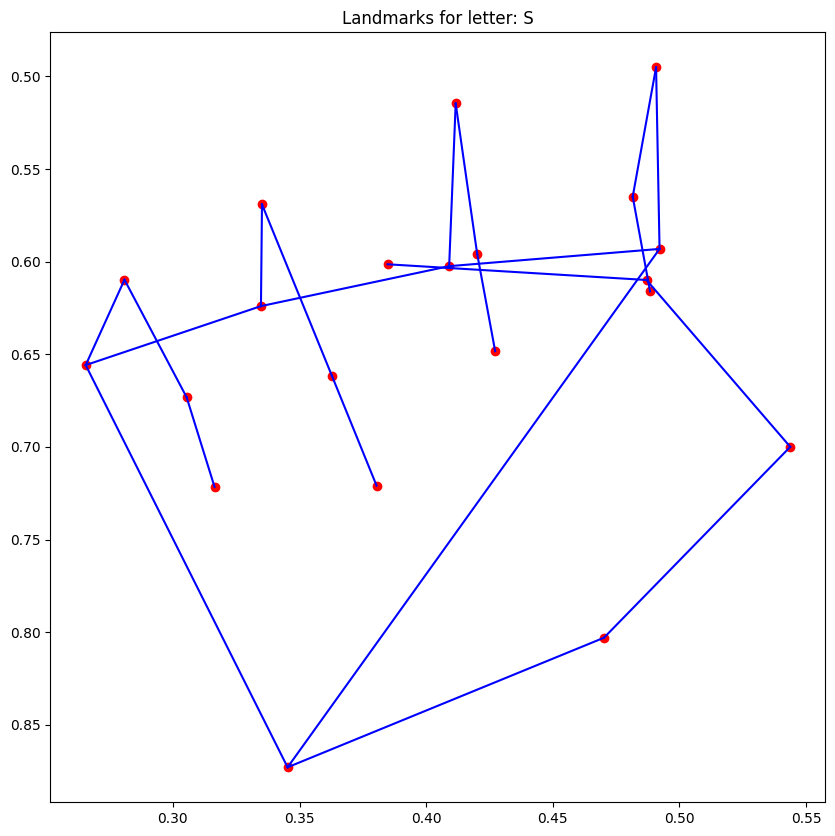

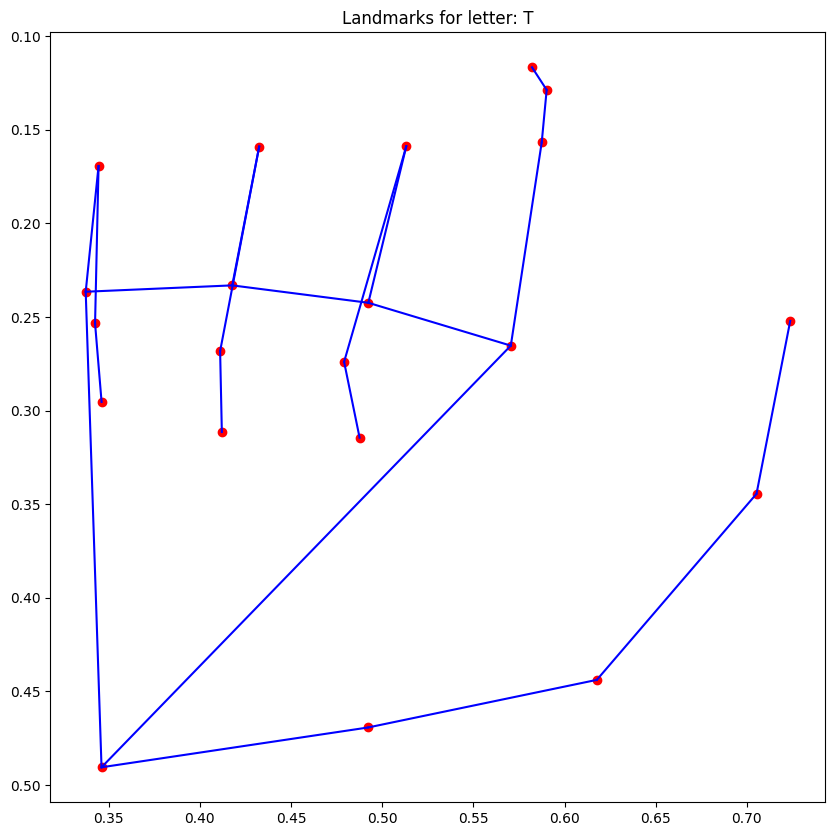

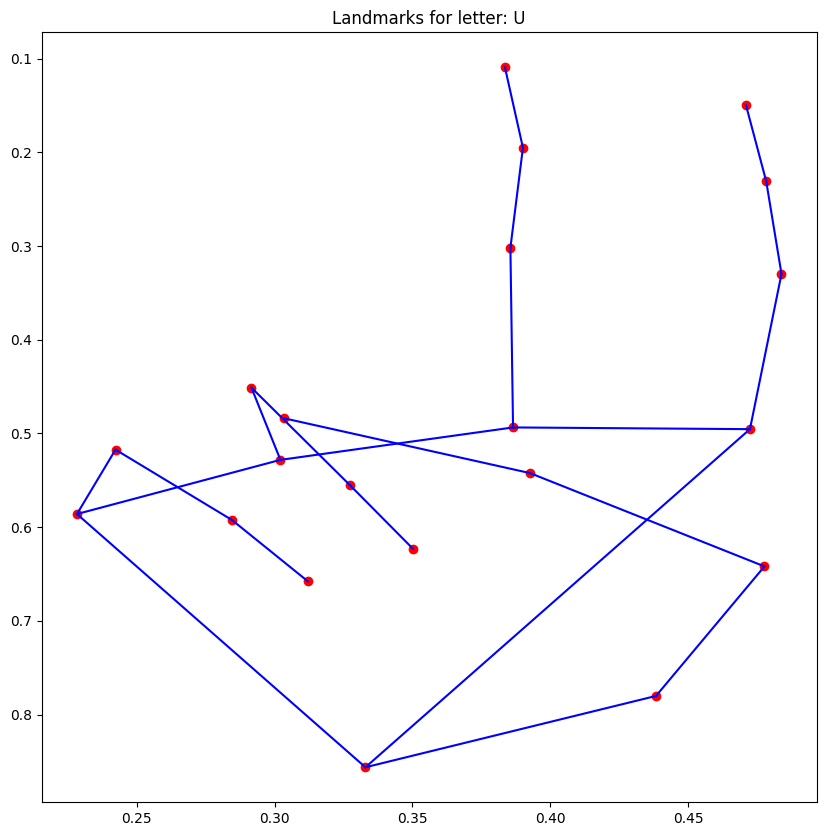

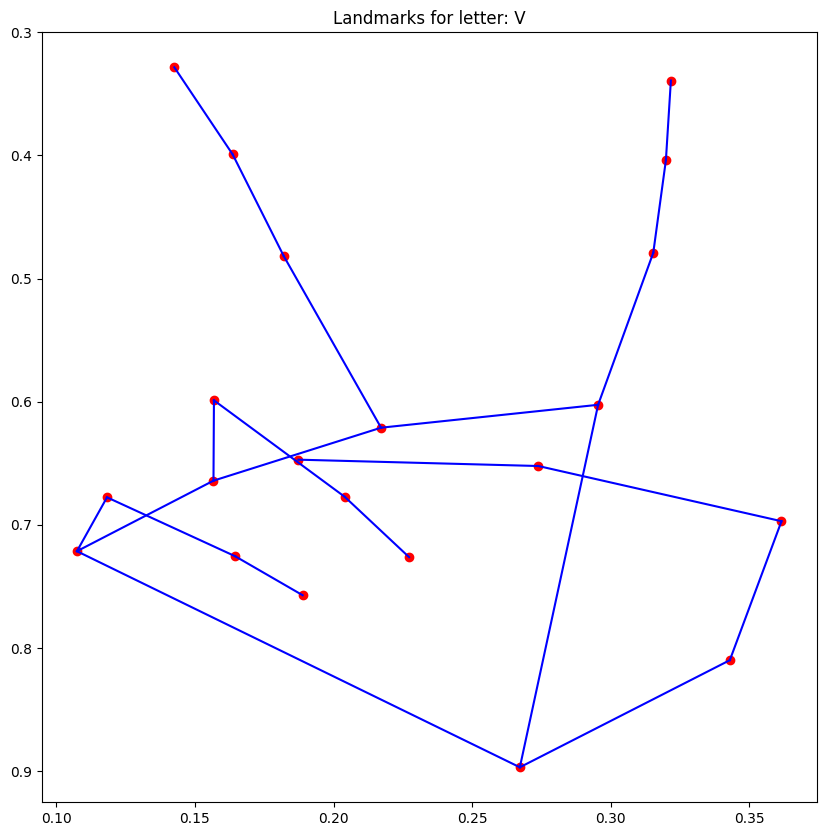

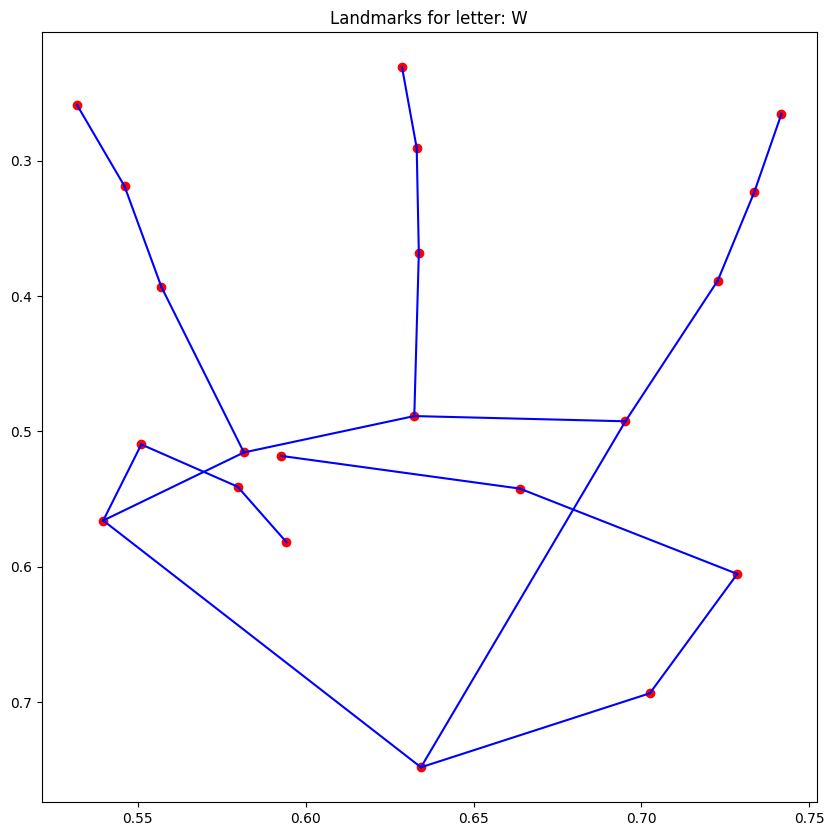

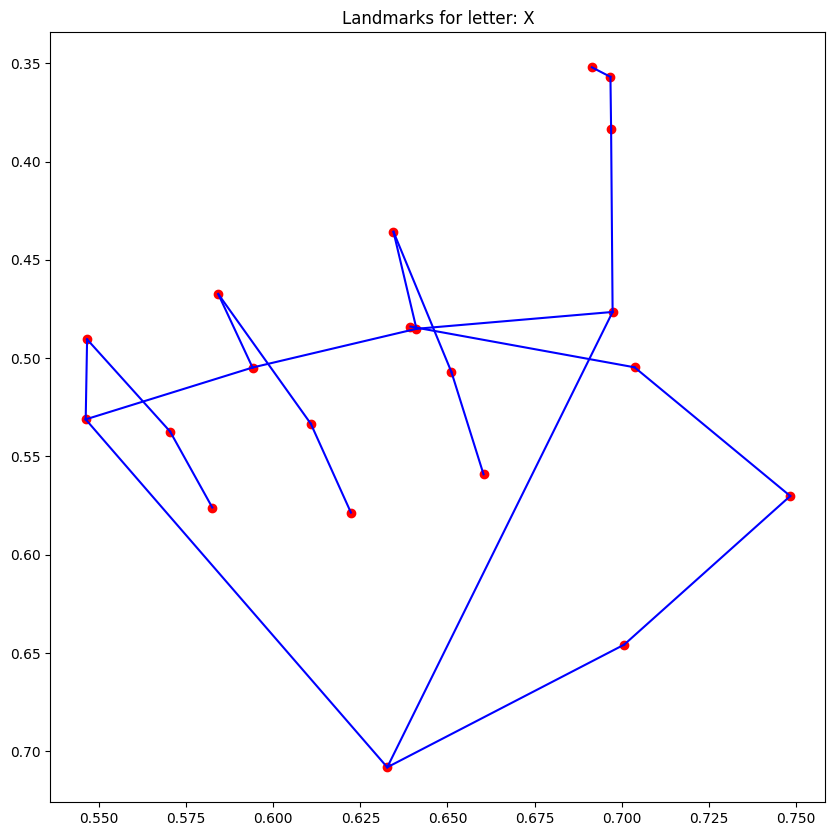

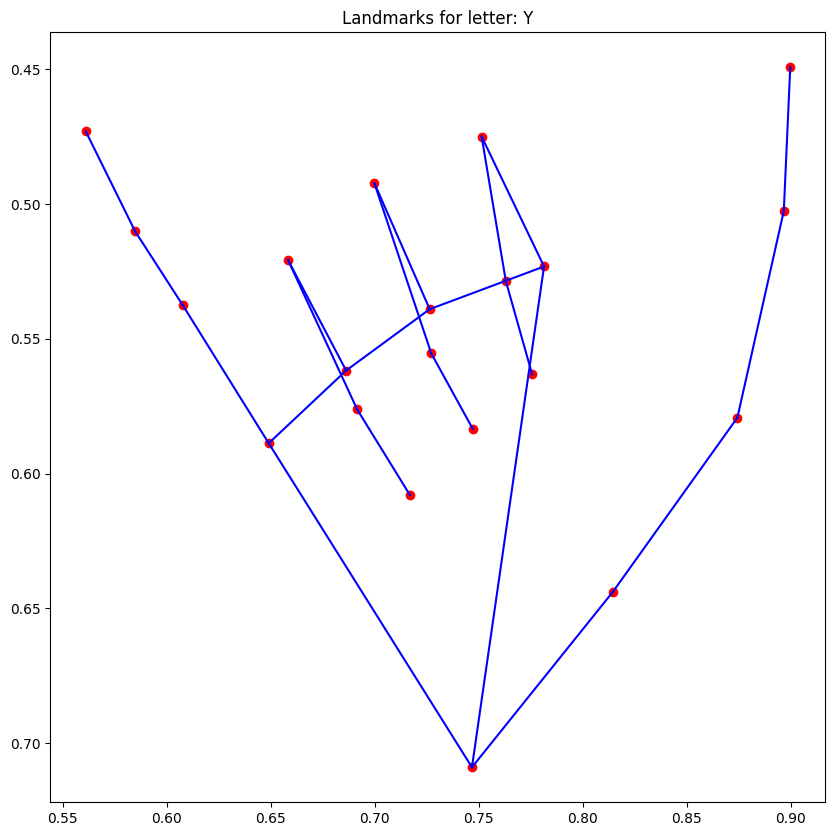

In [6]:
import matplotlib.pyplot as plt
import numpy as np

keypoint_connections = {
            (0, 1), (1, 2), (2, 3), (3, 4),      
            (0, 5), (5, 6), (6, 7), (7, 8),        
            (9, 10), (10, 11), (11, 12),
            (13, 14), (14, 15), (15, 16),        
            (0, 17), (17, 18), (18, 19), (19, 20),
            (5,9), (9,13), (13,17)  # Conexiones entre las bases de los dedos
        }

def show_landmarks(df_row):
    """  
    Show the hand landmarks for a given row of the DataFrame.

    Args:
        df_row (pd.Series): A row of the DataFrame containing the landmarks and the letter.
    """
    plt.figure(figsize=(10, 10))
    x = df_row[[f"landmark{i}_x" for i in range(21)]].values
    y = df_row[[f"landmark{i}_y" for i in range(21)]].values
    plt.scatter(x, y, c="red")
    for connection in keypoint_connections:
        i, j = connection
        plt.plot([x[i], x[j]], [y[i], y[j]], c="blue")
    plt.title(f"Landmarks for letter: {df_row['letter']}")
    plt.gca().invert_yaxis()  # Invertimos el eje y para que la mano se vea en la orientación correcta
    plt.show()

# Mostramos un dibujo de las coordenadas de los landmarks para una imagen de cada clase.
for letter in balanced_silver_df["letter"].unique():
    df_row = balanced_silver_df[balanced_silver_df["letter"] == letter].iloc[0]
    show_landmarks(df_row)

Si observamos los dibujos con la extracción de los landmarks utilizando el [landmark_detector.py](../src/silver/landmark_detector.py), podemos comprobar que la extracción de los landmarks se ha realizado correctamente, ya que las coordenadas de los landmarks coinciden con la posición de los dedos en la imagen original. Esto nos da confianza en que los datos de la capa `Silver` están correctamente procesados y listos para ser utilizados en la capa `Gold`.

Además, podemos ver que algunas clases son muy similares entre sí, lo que podría dificultar la tarea de clasificación y requerir de un análisis más detallado para tratar de discriminar correctamente entre estas clases.